# Projet : Modèle de Scoring Crédit – *Prêt à dépenser* - Suite

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import missingno as msno
import matplotlib.pyplot as plt

import mlflow
import mlflow.sklearn
from mlflow.models import infer_signature
from mlflow.models.evaluation import evaluate
import shap
import gc

from sklearn.impute import SimpleImputer
from sklearn import metrics
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, recall_score, f1_score, precision_score, roc_auc_score, roc_curve, make_scorer
from sklearn.model_selection import KFold, StratifiedKFold, GridSearchCV
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
import lightgbm
from lightgbm import LGBMClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from IPython.display import Image, display

from evidently.report import Report
from evidently.metrics import DataDriftTable, DatasetDriftMetric

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
import fonctions as fc
import importlib

In [4]:
import sys
print(sys.executable)

C:\Users\steph\anaconda3\python.exe


In [6]:
importlib.reload(fc)

<module 'fonctions' from 'C:\\Users\\steph\\Documents\\OPENCLASSROOMS\\Projets\\Projet7_Implémenter_un_modèle_de_scoring\\fonctions.py'>

In [8]:
# df = pd.read_csv('df_merge.csv')

In [10]:
# df.head()

In [12]:
# Supprimer les colonnes avec plus de 70% de valeurs manquantes
# missing_percentages = df.isnull().mean() * 100
# columns_to_drop = missing_percentages[missing_percentages > 60].index
# df = df.drop(columns=columns_to_drop)

# Afficher le DataFrame après suppression des colonnes
# df.info()

In [14]:
# Réduire automatiquement la taille des types de données numériques
# for col in df.select_dtypes(include=['float64']):
     # df[col] = pd.to_numeric(df[col], downcast='float')

# for col in df.select_dtypes(include=['int64']):
    # df[col] = pd.to_numeric(df[col], downcast='integer')

# print(df.info(memory_usage='deep'))

In [16]:
# feature_importance_df = pd.read_csv('df_feature_importance_lightGBM.csv')
# feature_importance_df.head()

In [18]:
# Réprésentation graphique des 100 features les plus importances : 
# col = feature_importance_df[["feature", "importance"]].groupby("feature").mean().sort_values(by="importance", ascending=False)[:100].index.tolist()
# best_features = feature_importance_df.loc[feature_importance_df['feature'].isin(col)]
# best_features = best_features.groupby('feature')['importance'].mean().to_frame('importance').sort_values('importance', ascending=False)

# plt.figure(figsize=(10, 16))
# sns.barplot(x="importance", y=best_features.index, data=best_features)
# plt.title('Features importance par LightGBM (moyenne sur 7 folds)')
# plt.tight_layout()
# plt.show()

# del col 

In [20]:
# Sélection de features :  
# df_selected_features = df.loc[:,best_features.index]

# Calcul de la matrice de corréaltion :
# correlation_matrix = df_selected_features.corr()

# Récupération des paires de variables fortement corrélées :
# correlated_pairs = set()

# for i in range(len(best_features.index)):
    
    # for j in range(i + 1, len(best_features.index)):
        # feature1 = best_features.index[i]
        # feature2 = best_features.index[j]
        # correlation = correlation_matrix.loc[feature1, feature2]
       
        # if abs(correlation) > 0.6: 
            # correlated_pairs.add((feature1, feature2))


# Sélection des features à éliminées : 
# features_to_remove = set()

# for pair in correlated_pairs:
    # feature1, feature2 = pair
    
    # Sélection de la variables à éliminer en fonction de son importance :
    # if best_features.loc[feature1, 'importance'] < best_features.loc[feature2, 'importance']: 
        # features_to_remove.add(feature1)
    # else: 
        # features_to_remove.add(feature2)

# print(f"Sur {len(best_features)} variables possédant le plus d\'importances, nous pouvons en éliminer {len(features_to_remove)}"
      # f" qui ont une corrélation importantes avec les autres\n")

# print(f"Liste ds features à garder : ")
# display(best_features.loc[~best_features.index.isin(list(features_to_remove))].sort_values('importance', ascending=False))

# del correlated_pairs, correlation, correlation_matrix, df_selected_features, feature1, feature2, i, j, pair

- Sur les 100 variables initialement sélectionnées comme les plus importantes, nous avons identifié des redondances fortes (corrélation > 0.6).  
Après élimination systématique de la variable la moins informative dans chaque paire corrélée, il reste **45** variables pertinentes, non redondantes et mieux adaptées à l’entraînement du modèle.

In [23]:
# Evaluation avec LightGBM : 

# 1. Récupération des features à garder : 
# ls_features = [f for f in best_features.index if f not in features_to_remove]
# ls_features.append('TARGET')

# 2. Filtre sur data : 
# df_filtre = df.loc[:, ls_features]

# 3. Evalutation : 
# _ = fc.features_importance_lightgbm(df_filtre, num_folds=7)

In [25]:
# Suppression des variables : 
#del best_features, df, feature_importance_df, features_to_remove, ls_features

### Résultats LightGBM avec 46 features

- **Train / Test** : 307 507 / 48 744 lignes  
- **AUC moyen** : 0.761 (folds : 0.754 – 0.766)  
- **Matrice de confusion** : 281 204 TN, 1 478 FP, 23 506 FN, 1 319 TP  

**Commentaire** : le modèle est robuste et performant sur les features sélectionnées, mais présente encore des faux négatifs à surveiller.


- Au vu de la faible perte de performance, nous garderons donc pour la suite les 45 variables.

In [29]:
df_filtre = pd.read_csv("df_filtre.csv")
print(df_filtre.shape)
df_filtre.head()

(356251, 46)


,EXT_SOURCE_3,EXT_SOURCE_2,PAYMENT_RATE,DAYS_BIRTH,EXT_SOURCE_1,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,ANNUITY_INCOME_PERC,INSTAL_DBD_MEAN,...,PREV_AMT_ANNUITY_MIN,INSTAL_AMT_INSTALMENT_MAX,PREV_NAME_TYPE_SUITE_Unaccompanied_MEAN,INSTAL_PAYMENT_PERC_VAR,HOUR_APPR_PROCESS_START,PREV_NAME_TYPE_SUITE_nan_MEAN,TOTALAREA_MODE,PREV_NAME_YIELD_GROUP_middle_MEAN,PREV_RATE_DOWN_PAYMENT_MEAN,TARGET
0,0.139376,0.262949,0.060749,-9461,0.083037,-637.0,-3648.0,-2120,0.121978,20.421053,...,9251.775,53093.745,0.000000,0.000000,10,1.000000,0.0149,0.000000,0.000000,1.0
1,NaN,0.622246,0.027598,-16765,0.311267,-1188.0,-1186.0,-291,0.132217,7.160000,...,6737.310,560835.360,0.333333,0.000000,11,0.000000,0.0714,0.666667,0.050030,0.0
2,0.729567,0.555912,0.050000,-19046,NaN,-225.0,-4260.0,-2531,0.100000,7.666666,...,5357.250,10573.965,1.000000,0.000000,9,0.000000,NaN,1.000000,0.212008,0.0
3,NaN,0.650442,0.094941,-19005,NaN,-3039.0,-9833.0,-2437,0.219900,19.375000,...,2482.920,691786.890,0.333333,0.000000,17,0.555556,NaN,0.111111,0.163412,0.0
4,NaN,0.322738,0.042623,-19932,NaN,-3038.0,-4311.0,-3458,0.179963,4.590909,...,1834.290,22678.785,0.333333,0.043995,11,0.333333,NaN,0.500000,0.159516,0.0


## V- Preprocessing

In [32]:
df_filtre.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 356251 entries, 0 to 356250
Data columns (total 46 columns):
 #   Column                                   Non-Null Count   Dtype  
---  ------                                   --------------   -----  
 0   EXT_SOURCE_3                             286618 non-null  float64
 1   EXT_SOURCE_2                             355583 non-null  float64
 2   PAYMENT_RATE                             356215 non-null  float64
 3   DAYS_BIRTH                               356251 non-null  int64  
 4   EXT_SOURCE_1                             162343 non-null  float64
 5   DAYS_EMPLOYED                            291603 non-null  float64
 6   DAYS_REGISTRATION                        356251 non-null  float64
 7   DAYS_ID_PUBLISH                          356251 non-null  int64  
 8   ANNUITY_INCOME_PERC                      356215 non-null  float64
 9   INSTAL_DBD_MEAN                          339583 non-null  float64
 10  AMT_ANNUITY                     

<Axes: >

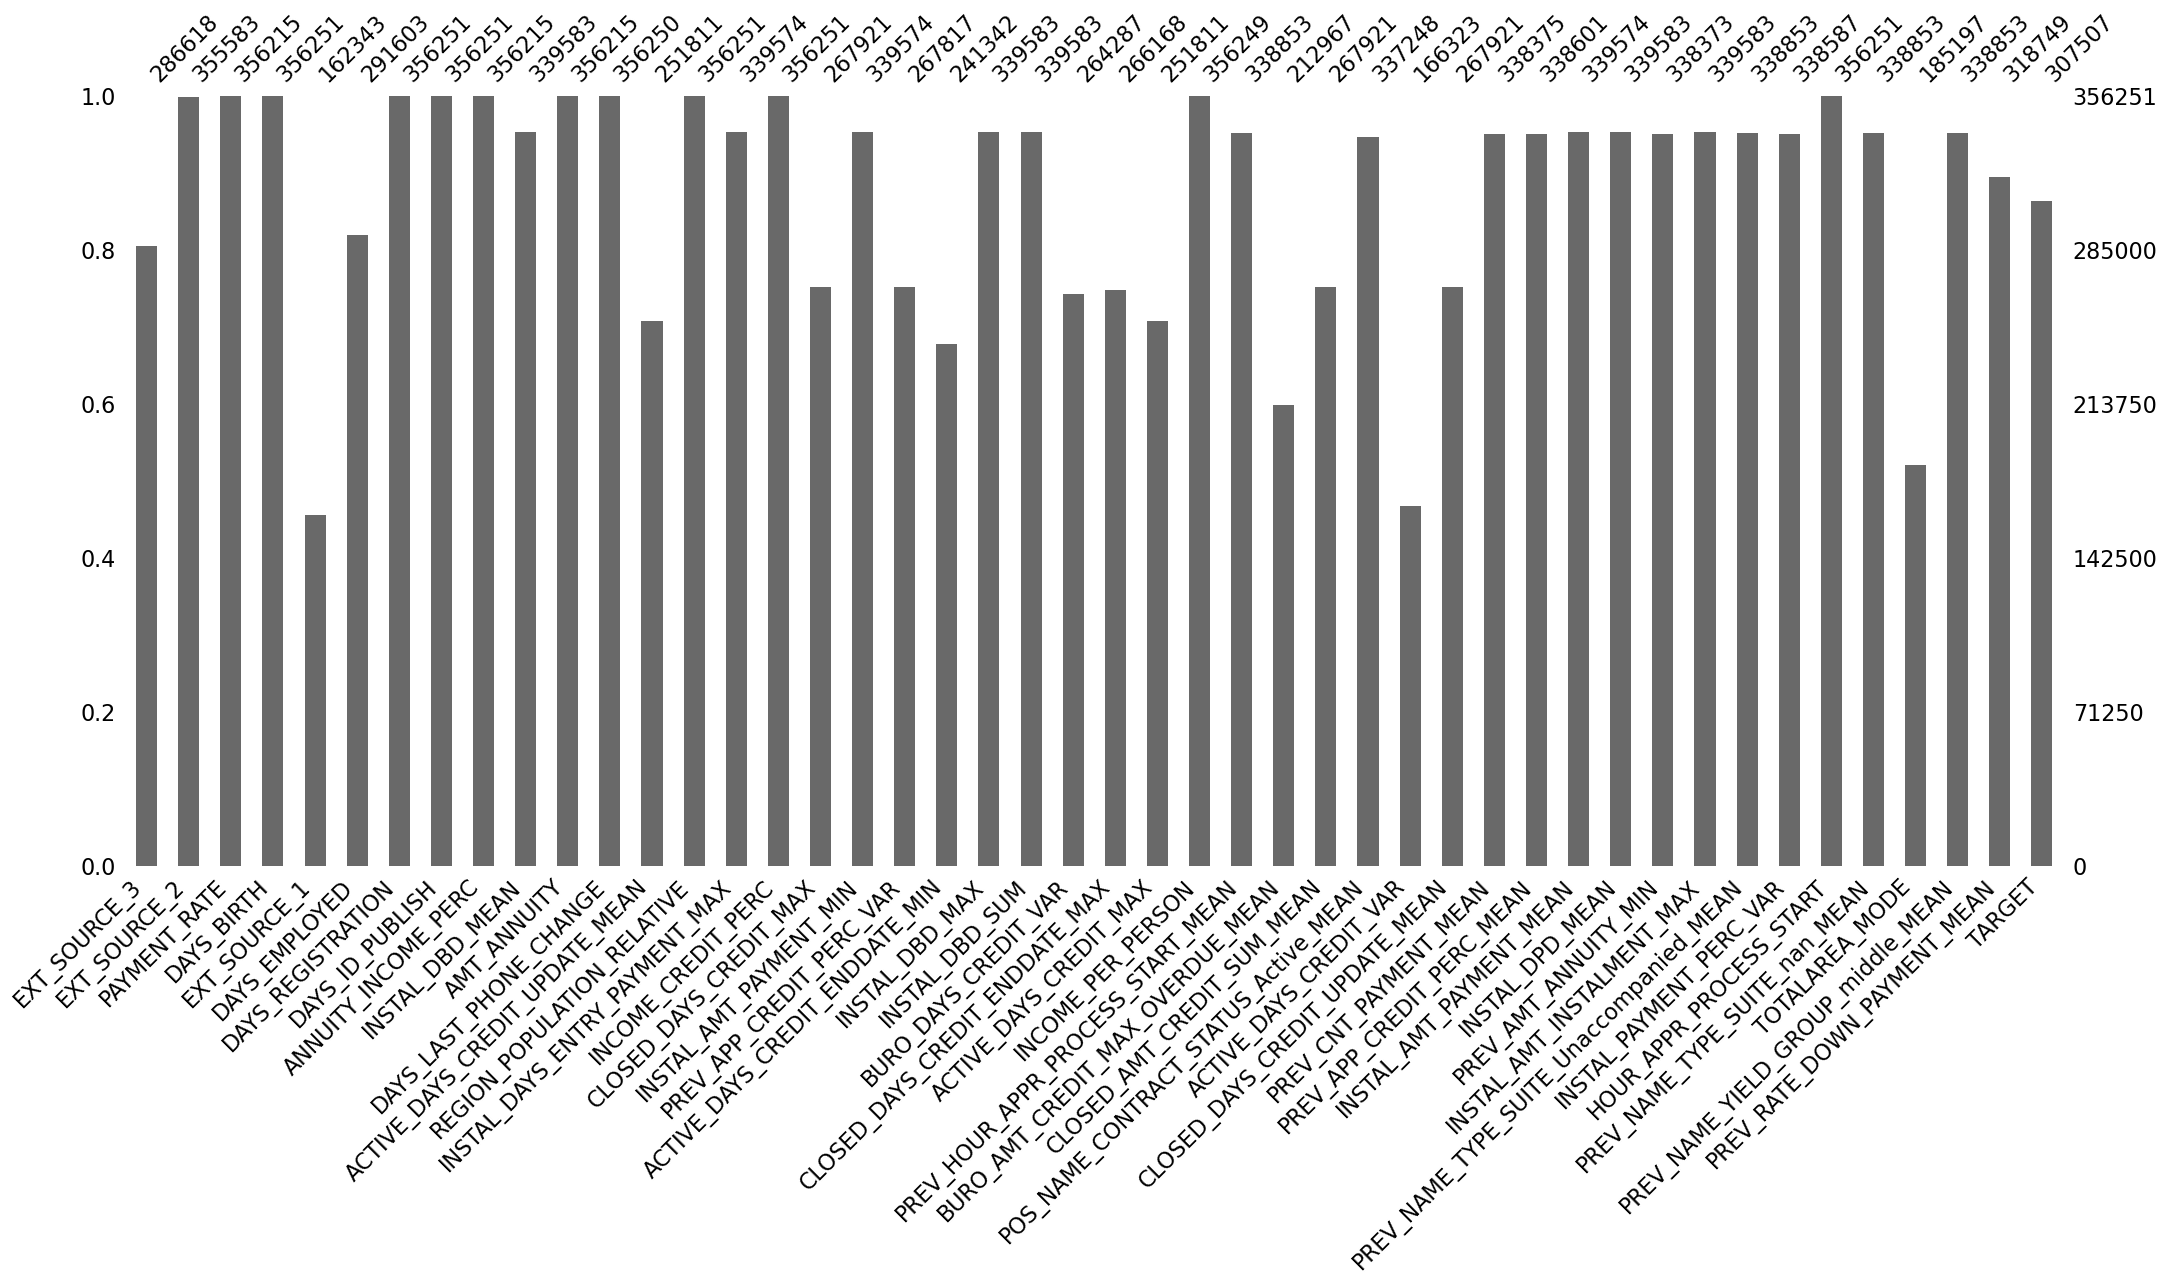

In [34]:
msno.bar(df_filtre)

### Préprocessing après sélection des 45 features

- **Données finales** : 356 251 lignes, 46 colonnes (45 features + TARGET)  
- **Types de données** : 32 float32, 11 float64, 2 int16, 1 int8  
- **Valeurs manquantes** : certaines colonnes conservent des NaN (ex. EXT_SOURCE_1, TOTALAREA_MODE, ACTIVE_DAYS_CREDIT_UPDATE_MEAN)  
- **Mémoire utilisée** : ~78 MB après downcast automatique  

**Commentaire** : le dataset est optimisé pour la mémoire et prêt pour les étapes suivantes de modélisation et d’imputation des valeurs manquantes.


In [37]:
# Complétion par la moyenne : 
train_mean_imputed, test_mean_imputed = fc.pre_process_dataframe(df_filtre, fillna_strategy='mean')
print(f"Dimension train : {train_mean_imputed.shape}")
print(f"Dimension test : {test_mean_imputed.shape}")

****************************************************************************************************

TRAIN
Nombre de colonnes avec au moins une valeur manquante : 0
type de données : [dtype('float32'), dtype('int8')]

****************************************************************************************************
****************************************************************************************************

TEST
Nombre de colonnes avec au moins une valeur manquante : 0
type de données : [dtype('float32'), dtype('int8')]

****************************************************************************************************
Dimension train : (307507, 46)
Dimension test : (48744, 45)


In [39]:
# Complétion par la médianne : 
train_median_imputed, test_median_imputed = fc.pre_process_dataframe(df_filtre, fillna_strategy='median')
print(f"Dimension train : {train_median_imputed.shape}")
print(f"Dimension test : {test_median_imputed.shape}")

****************************************************************************************************

TRAIN
Nombre de colonnes avec au moins une valeur manquante : 0
type de données : [dtype('float32'), dtype('int8')]

****************************************************************************************************
****************************************************************************************************

TEST
Nombre de colonnes avec au moins une valeur manquante : 0
type de données : [dtype('float32'), dtype('int8')]

****************************************************************************************************
Dimension train : (307507, 46)
Dimension test : (48744, 45)


In [40]:
# Complétion par le mode : 
train_mode_imputed, test_mode_imputed = fc.pre_process_dataframe(df=df_filtre, 
                                                              fillna_strategy='mode',
                                                              )

print(f"Dimension train : {train_mode_imputed.shape}")
print(f"Dimension test : {test_mode_imputed.shape}")

****************************************************************************************************

TRAIN
Nombre de colonnes avec au moins une valeur manquante : 0
type de données : [dtype('float32'), dtype('int8')]

****************************************************************************************************
****************************************************************************************************

TEST
Nombre de colonnes avec au moins une valeur manquante : 0
type de données : [dtype('float32'), dtype('int8')]

****************************************************************************************************
Dimension train : (307507, 46)
Dimension test : (48744, 45)


In [42]:
# Enregistrement des df
train_mean_imputed.to_csv('train_mean_imputed.csv', index=False)
train_median_imputed.to_csv('train_median_imputed.csv', index=False)
train_mode_imputed.to_csv('train_mode_imputed.csv', index=False)

test_mean_imputed.to_csv('test_mean_imputed.csv', index=False)
test_median_imputed.to_csv('test_median_imputed.csv', index=False)
test_mode_imputed.to_csv('test_mode_imputed.csv', index=False)

## Complétion des valeurs manquantes

Pour préparer nos données avant modélisation, nous avons appliqué trois stratégies d’imputation sur le dataset filtré (`df_filtre`) :

1. **Moyenne (`mean`)**  
2. **Médiane (`median`)**  
3. **Mode (`mode`)**  

Chaque stratégie a été appliquée séparément sur les données d’entraînement et de test. Après imputation :  

- **Train** : 307 507 lignes et 46 colonnes, aucune valeur manquante.  
- **Test** : 48 744 lignes et 45 colonnes, aucune valeur manquante.  

> Remarque : la différence d’une colonne entre train et test correspond à la présence de la variable cible `TARGET` uniquement dans le train.

Les types de données restent majoritairement `float32` et `int16`, avec quelques colonnes passées ponctuellement en `float64` lors de l’imputation. Cela n’affecte pas la suite du traitement.

Les fichiers imputés ont été enregistrés pour les trois stratégies afin d’être utilisés dans les étapes suivantes :  

- `train_mean_imputed.csv` / `test_mean_imputed.csv`  
- `train_median_imputed.csv` / `test_median_imputed.csv`  
- `train_mode_imputed.csv` / `test_mode_imputed.csv`


## VI- Selection du dataset

In [47]:
# Importation des données
train_mean = pd.read_csv('train_mean_imputed.csv')
train_median = pd.read_csv('train_median_imputed.csv')
train_mode = pd.read_csv('train_mode_imputed.csv')

# Création du dictionnaire
dict_data = {
    'train_mean': train_mean,
    'train_median': train_median,
    'train_mode': train_mode
}

In [49]:
best_accuracy = 0 
best_df = None

for name, df in dict_data.items(): 
    # Création du modèle : 
    model = LogisticRegression(random_state=42)
    
    # Preprocessing de df : 
    X_train, X_test, y_train, y_test = fc.preprocess_data(df)
    
    # Entrainement et prediction : 
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    # Calcul de l'accuracy : 
    accuracy = accuracy_score(y_test, y_pred)
    
    # Mise à jour du meilleur dataset : 
    if accuracy > best_accuracy: 
        best_accuracy = accuracy
        best_df = name

print(f"Le dataset sélectionné est {best_df}")

# Nettoyage des variables inutiles : 
del accuracy, best_accuracy, best_df, df, dict_data, model, name, X_test, X_train, y_test, y_train, y_pred

Le dataset sélectionné est train_mean


In [51]:
train_mean.describe()

,EXT_SOURCE_3,EXT_SOURCE_2,PAYMENT_RATE,DAYS_BIRTH,EXT_SOURCE_1,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,ANNUITY_INCOME_PERC,INSTAL_DBD_MEAN,...,PREV_AMT_ANNUITY_MIN,INSTAL_AMT_INSTALMENT_MAX,PREV_NAME_TYPE_SUITE_Unaccompanied_MEAN,INSTAL_PAYMENT_PERC_VAR,HOUR_APPR_PROCESS_START,PREV_NAME_TYPE_SUITE_nan_MEAN,TOTALAREA_MODE,PREV_NAME_YIELD_GROUP_middle_MEAN,PREV_RATE_DOWN_PAYMENT_MEAN,TARGET
count,307507.000000,3.075070e+05,307507.000000,307507.000000,307507.000000,307507.000000,307507.000000,307507.000000,307507.000000,307507.000000,...,307507.000000,3.075070e+05,307507.000000,3.075070e+05,307507.000000,307507.000000,307507.000000,307507.000000,307507.000000,307507.00000
mean,0.510856,5.143918e-01,0.053695,-0.340184,0.502129,-2384.142263,-4986.131376,-0.777312,0.180931,12.265640,...,7864.340806,1.363393e+05,0.284513,2.077051e+04,12.063394,0.479407,0.102548,0.254911,0.081924,0.08073
std,0.174463,1.908552e-01,0.022481,74.011834,0.139396,2117.349523,3522.883030,73.878177,0.094572,8.903555,...,7279.861890,2.390613e+05,0.288693,3.242692e+06,3.265835,0.320717,0.077292,0.285937,0.084439,0.27242
min,0.000527,8.173617e-08,0.022073,-128.000000,0.014568,-17912.000000,-24672.000000,-128.000000,0.000224,0.000000,...,0.000000,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,-0.000007,0.00000
25%,0.417100,3.929737e-01,0.036900,-65.000000,0.502129,-2760.000000,-7479.500000,-65.000000,0.114787,6.857143,...,3633.345000,1.468577e+04,0.000000,0.000000e+00,10.000000,0.250000,0.067000,0.000000,0.000000,0.00000
50%,0.510856,5.654672e-01,0.050000,0.000000,0.502129,-2219.000000,-4504.000000,-2.000000,0.162833,10.529411,...,6073.380000,4.004266e+04,0.250000,1.115377e-02,12.000000,0.500000,0.102548,0.200000,0.081924,0.00000
75%,0.636376,6.634218e-01,0.064043,64.000000,0.502129,-933.000000,-2010.000000,63.000000,0.229067,14.750000,...,9150.412500,1.363393e+05,0.500000,1.100713e-01,14.000000,0.666667,0.102548,0.384615,0.107782,0.00000
max,0.896010,8.549997e-01,0.124430,127.000000,0.962693,0.000000,0.000000,127.000000,1.875965,295.000000,...,300425.440000,3.771488e+06,1.000000,9.675044e+08,23.000000,1.000000,1.000000,1.000000,0.989740,1.00000


- Nous avons comparé les trois datasets imputés (`mean`, `median`, `mode`) en utilisant une régression logistique et en calculant l’accuracy.  

Le dataset **`train_mean`** a obtenu la meilleure performance et est donc sélectionné pour la suite.  

Une rapide analyse descriptive du dataset sélectionné montre :  
- 307 507 lignes et 46 colonnes.  
- Les variables continues ont des valeurs cohérentes avec leurs distributions attendues (ex : `EXT_SOURCE_3` entre 0 et 0.896, `DAYS_BIRTH` entre -128.000  et 127.000).  
- Les colonnes ont été correctement imputées et sont prêtes pour les étapes de modélisation.


## VII- Modélisation

- D'abord, on sépare nos données en train et test, et on applique un StandardScaler

In [56]:
X_train, X_test, y_train, y_test = fc.preprocess_data(train_mean)

In [58]:
def logToMLflow(model, X_train, X_test, y_train, y_test, name="", params="", training_tag="", thresholds=np.linspace(0, 1, 100),  experiment_name="Default"):
    """Fonction de logging d'une expérimentation vers MLFlow."""
    mlflow.set_experiment(experiment_name)
        
    # Start an MLflow run
    with mlflow.start_run(run_name=name):
        # Log the hyperparameters
        if params:
            mlflow.log_params(params)
        
        model_fit = model.fit(X_train, y_train)
        
        # infer model signature
        signature = infer_signature(X_train, model_fit.predict(X_train))
        
        # Optimiser le seuil métier
        best_threshold_train, best_score_train, _ = fc.seuil_metier(model_fit, X_train, y_train, thresholds)

        # Prédiction sur le set de test avec le seuil optimal
        y_pred_proba_test = model_fit.predict_proba(X_test)[:, 1]
        y_pred_test = np.where(y_pred_proba_test > best_threshold_train, 1, 0)
        
        # Calcul et enregistrement des metriques 
        metier, accuracy, precision, recall, f1_score, fbeta_score, rocauc, y_pred_proba = fc.eval_score(model_fit, X_test, y_test)
   
        mlflow.log_metric("score_métier", metier)
        mlflow.log_metric("accuracy", accuracy)
        mlflow.log_metric("precision", precision)
        mlflow.log_metric("recall", recall)
        mlflow.log_metric("f1_score", f1_score)
        mlflow.log_metric("fbeta_score", fbeta_score)
        mlflow.log_metric("rocauc", rocauc)
        mlflow.log_metric("best_threshold", best_threshold_train)
        mlflow.log_metric("best_score_metier", best_score_train)
        
        # Set a tag that we can use to remind ourselves what this run was for
        if training_tag:
            mlflow.set_tag("Training Info", training_tag)

        # construct an evaluation dataset from the test set
        eval_data = X_test.copy()
        eval_data['target'] = y_test.values
        
        # Log the model
        mlflow.sklearn.log_model(model_fit, name='model', signature=signature)
        model_info = mlflow.sklearn.log_model(model_fit, name='model', signature=signature)
        
        result = mlflow.evaluate(
            model_info.model_uri,
            eval_data,
            targets="target",
            model_type="classifier",
            evaluators=["default"],
        )

Training Dummy Classifier...
Score métier :0.81
Accuracy score : 0.92
Precision score : 1.00
Recall score : 0.00
F1 score : 0.00
Fbeta score : 0.00
ROC AUC score : 0.50


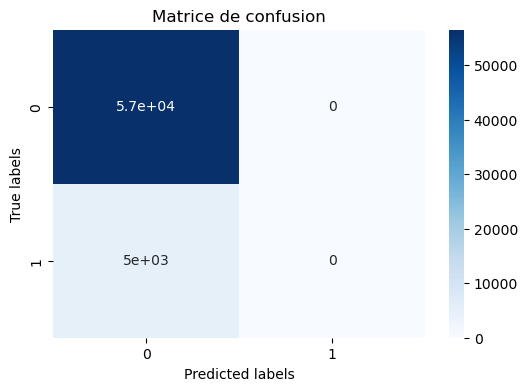

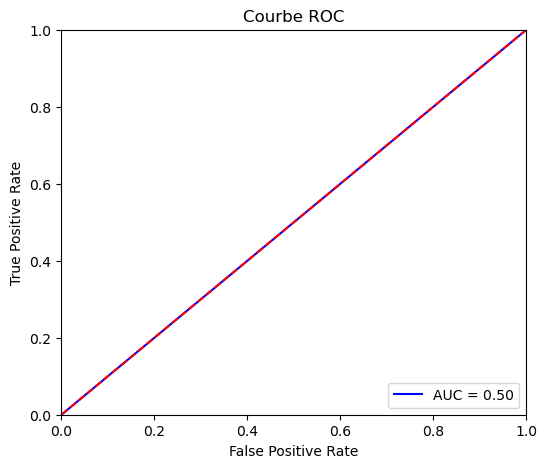

2025/10/03 08:30:19 INFO mlflow.tracking.fluent: Active model is set to the logged model with ID: m-f5f8c36df0d74c28bc03ae2b3cbccd9d
2025/10/03 08:30:19 INFO mlflow.tracking.fluent: Use `mlflow.set_active_model` to set the active model to a different one if needed.
C:\Users\steph\anaconda3\Lib\site-packages\mlflow\types\utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more detai

Dummy Classifier training complete.
Training Logistic Regression...
Score métier :0.80
Accuracy score : 0.92
Precision score : 0.49
Recall score : 0.01
F1 score : 0.02
Fbeta score : 0.01
ROC AUC score : 0.74


<Figure size 1050x700 with 0 Axes>

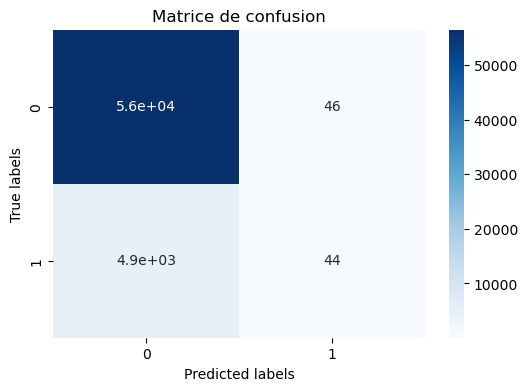

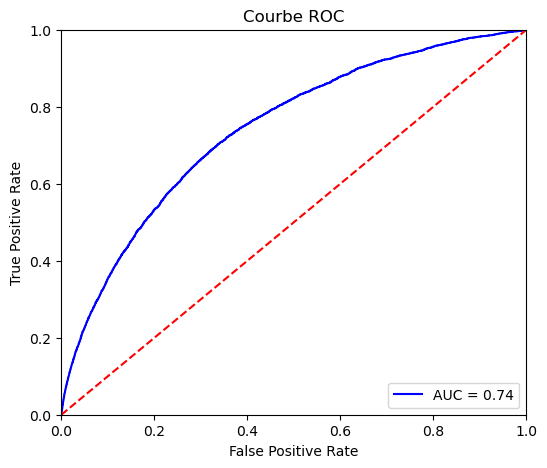

2025/10/03 08:31:03 INFO mlflow.tracking.fluent: Active model is set to the logged model with ID: m-059b8c6ad0f14c419ef8c7147492c367
2025/10/03 08:31:03 INFO mlflow.tracking.fluent: Use `mlflow.set_active_model` to set the active model to a different one if needed.
C:\Users\steph\anaconda3\Lib\site-packages\mlflow\types\utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more detai

Logistic Regression training complete.
Training Decision Tree...
Score métier :0.75
Accuracy score : 0.86
Precision score : 0.15
Recall score : 0.15
F1 score : 0.15
Fbeta score : 0.15
ROC AUC score : 0.55


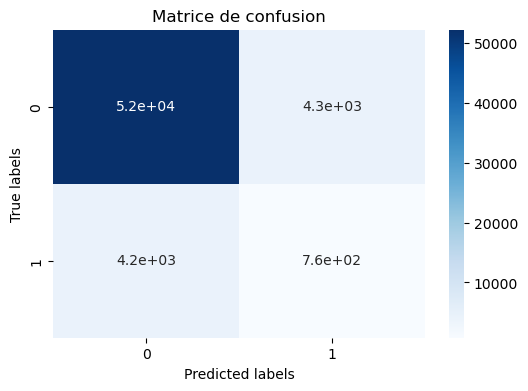

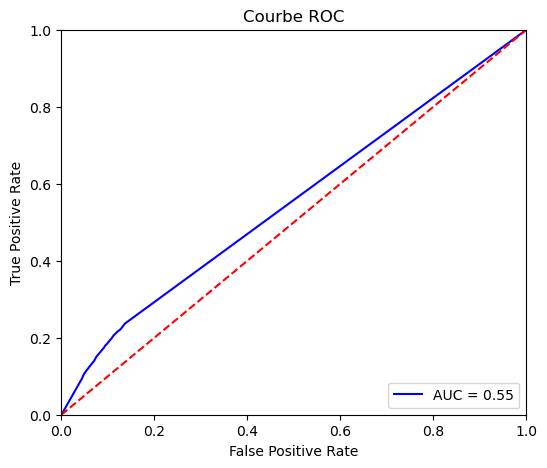

2025/10/03 08:32:17 INFO mlflow.tracking.fluent: Active model is set to the logged model with ID: m-56b7008982c340bbb8a7ce5f398f3df9
2025/10/03 08:32:17 INFO mlflow.tracking.fluent: Use `mlflow.set_active_model` to set the active model to a different one if needed.
C:\Users\steph\anaconda3\Lib\site-packages\mlflow\types\utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more detai

Decision Tree training complete.
Training RandomForest...
Score métier :0.81
Accuracy score : 0.92
Precision score : 0.53
Recall score : 0.00
F1 score : 0.00
Fbeta score : 0.00
ROC AUC score : 0.72


<Figure size 1050x700 with 0 Axes>

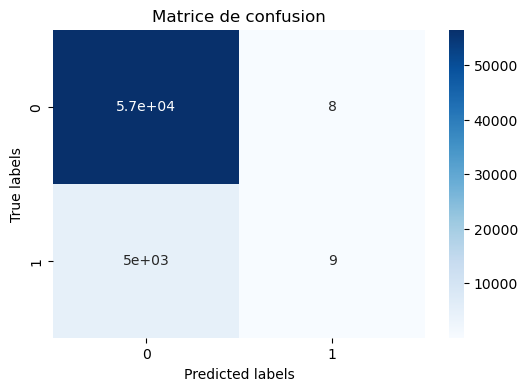

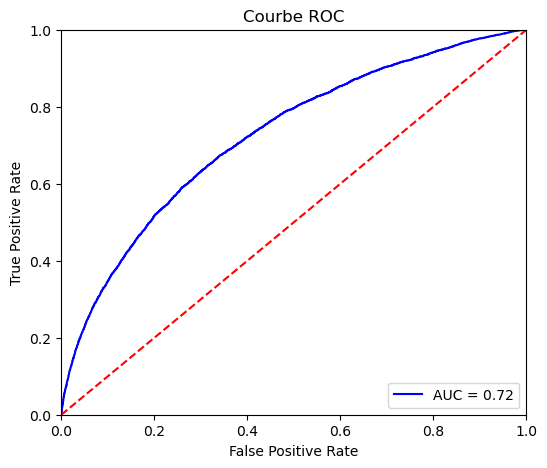

2025/10/03 08:39:11 INFO mlflow.tracking.fluent: Active model is set to the logged model with ID: m-26e2c11f349948b2a791b78fa9606d7c
2025/10/03 08:39:11 INFO mlflow.tracking.fluent: Use `mlflow.set_active_model` to set the active model to a different one if needed.
C:\Users\steph\anaconda3\Lib\site-packages\mlflow\types\utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more detai

RandomForest training complete.
Training XGBoost...
Score métier :0.78
Accuracy score : 0.92
Precision score : 0.46
Recall score : 0.04
F1 score : 0.08
Fbeta score : 0.05
ROC AUC score : 0.76


<Figure size 1050x700 with 0 Axes>

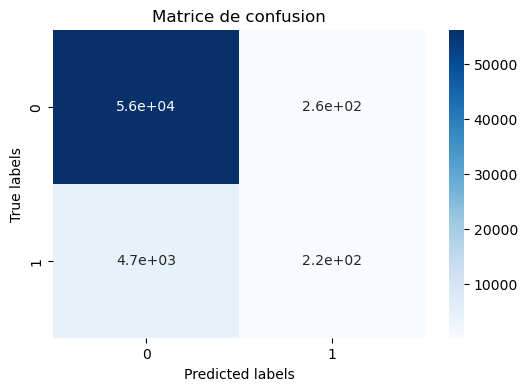

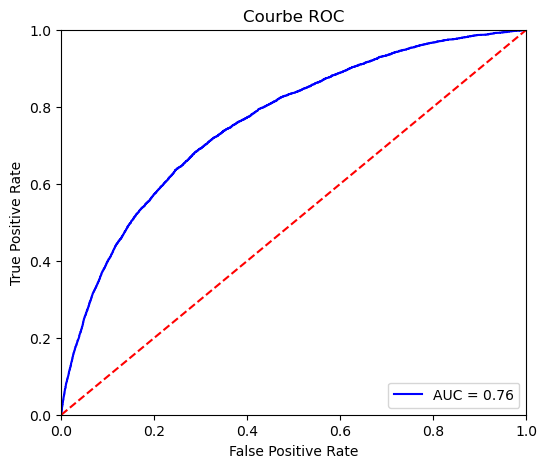

2025/10/03 08:54:50 INFO mlflow.tracking.fluent: Active model is set to the logged model with ID: m-96607b130a9e41058805852b666abcc7
2025/10/03 08:54:50 INFO mlflow.tracking.fluent: Use `mlflow.set_active_model` to set the active model to a different one if needed.
C:\Users\steph\anaconda3\Lib\site-packages\mlflow\types\utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more detai

XGBoost training complete.
Training LightGBM...
[LightGBM] [Info] Number of positive: 19860, number of negative: 226145
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.073796 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 10774
[LightGBM] [Info] Number of data points in the train set: 246005, number of used features: 45
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080730 -> initscore=-2.432469
[LightGBM] [Info] Start training from score -2.432469
Score métier :0.79
Accuracy score : 0.92
Precision score : 0.49
Recall score : 0.02
F1 score : 0.05
Fbeta score : 0.03
ROC AUC score : 0.77


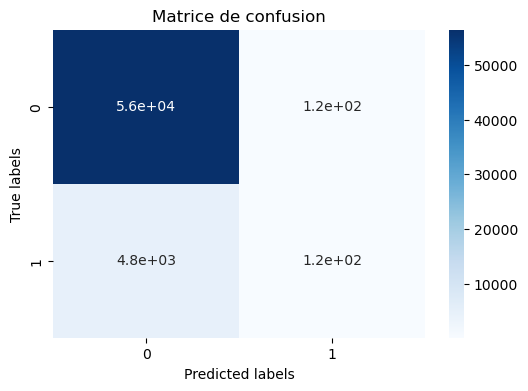

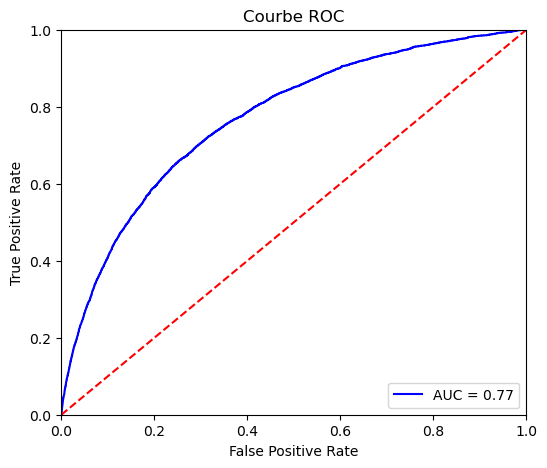

2025/10/03 08:55:52 INFO mlflow.tracking.fluent: Active model is set to the logged model with ID: m-79f402dcaeb24fe09fc2facef3d2b0f5
2025/10/03 08:55:52 INFO mlflow.tracking.fluent: Use `mlflow.set_active_model` to set the active model to a different one if needed.
C:\Users\steph\anaconda3\Lib\site-packages\mlflow\types\utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more detai

LightGBM training complete.


<Figure size 1050x700 with 0 Axes>

In [60]:
# Définition des modèles qu'on va comparer
models = {
    "Dummy Classifier" : DummyClassifier(random_state=42),
    "Logistic Regression" : LogisticRegression(random_state=42),
    "Decision Tree" : DecisionTreeClassifier(random_state=42, min_samples_split=10),
    "RandomForest": RandomForestClassifier(random_state=42, min_samples_split=10),
    "XGBoost" : XGBClassifier(random_state = 42, n_jobs =-1),
    "LightGBM" : LGBMClassifier(random_state=42),
}

# Parcours des modèles pour entraînement et logging
for name, model in models.items():
    print(f"Training {name}...")
    # Log the experiment
    logToMLflow(model, X_train, X_test, y_train, y_test, name)
    print(f"{name} training complete.")

# Analyse des modèles de scoring

Nous avons entraîné plusieurs modèles de classification sur le dataset `train_mean` et évalué leurs performances sur le jeu de test avec différents metrics, y compris le score métier et le ROC AUC.

## Observations principales

- **Dummy Classifier** : baseline. Score métier **0.81**, accuracy **0.92**, rappel **0.00**.  
  > Comme prévu, il prédit toujours la classe majoritaire, donc aucun défaut détecté.

- **Logistic Regression** : ROC AUC **0.74**, rappel **0.01**.  
  > Légèrement meilleur que la baseline en discrimination, mais quasi aucun défaut détecté.

- **Decision Tree** : Score métier **0.75**, ROC AUC **0.55**, rappel **0.15**.  
  > Amélioration du rappel par rapport à la baseline mais performance globale faible.

- **Random Forest** : Score métier **0.81**, ROC AUC **0.72**, rappel **0.00**.  
  > Même problème que la régression logistique : il prédit presque toujours la classe majoritaire.

- **XGBoost** : ROC AUC **0.76**, rappel **0.04**.  
  > Léger gain en rappel, mais encore insuffisant pour identifier correctement les clients à risque.

- **LightGBM** : Score métier **0.79**, ROC AUC **0.77**, rappel **0.02**.  
  > Meilleur modèle global, mais rappel très faible. Nécessite optimisation avant utilisation pour le scoring bancaire.

## Conclusion intermédiaire

- ✅ Aucun modèle n’est en **overfitting** (scores métier ≤ 0.82).  
- ⚠️ Tous les modèles ont un **rappel trop faible**, ce qui est critique dans un contexte bancaire : mieux vaut identifier les clients risqués, même au prix de faux positifs.  

## Prochaine étape : Optimisation des modèles

1. **Rééquilibrage des classes** :  
   - SMOTE, oversampling ou undersampling.  
   - `class_weight='balanced'` dans Logistic Regression, RandomForest, LightGBM.

2. **Optimisation des hyperparamètres** :  
   - LightGBM/XGBoost : `scale_pos_weight`, `num_leaves`, `max_depth`, `learning_rate`.  
   - RandomForest : `n_estimators`, `max_depth`, `min_samples_split`.

3. **Ajustement du seuil de décision** :  
   - Déplacer le seuil par défaut (0.5) pour améliorer le rappel.

4. **Évaluation métier** :  
   - Courbe Precision-Recall pour choisir le compromis entre rappel et précision.

> **Résumé :** LightGBM est le modèle le plus prometteur. La prochaine étape consiste à l’optimiser pour améliorer le rappel tout en gardant le score métier sous 0.82.


## VIII- Optimisation des modèles


**Étap àes réaleres :**

1. **Définition des hyperparamètres**
   - Pour chaque modèle (Logistic Regression, Decision Tree, RandomForest, XGBoost, LightGBM), nous avons défini un dictionnaire de combinaisons d’hyperparamètres à tester (`models_params`).

2. **Pipeline d’optimisation**
   - `StandardScaler` pour la mise à l’échelle des données.
   - `SMOTE` pour rééquilibrer les classes.
   - Le modèle choisi (Logistic Regression, RandomForest, etc.).

3. **Recherche des meilleurs hyperparamètres**
   - `GridSearchCV` teste toutes les combinaisons d’hyperparamètres avec validation croisée 5 folds.
   - Scoring basé sur le **score métier personnalisé** (`fc.score_metier`).

4. **Optimisation du seuil métier**
   - Après avoir trouvé le meilleur modèle, on ajuste le **seuil de décision** pour maximiser le score métier.
   - Cela permet d’améliorer le rappel tout en contrôlant la précision.

5. **Suivi MLflow**
   - Pour chaque modèle optimisé, nous enregistrons :
     - Meilleur score métier
     - Meilleur seuil
     - Meilleurs hyperparamètres
     - Score GridSearchCV

6. **Résultat**
   - Tous les modèles optimisés sont stockés dans un dictionnaire `optimized_models`.
   - Chaque modèle est prêt à être évalué ou utilisé pour la prédicton sur de nouvelles données.
édiction]


In [65]:
from imblearn.pipeline import Pipeline

def optimize_model(model, params, X_train, y_train, run_name, thresholds=np.linspace(0, 1, 100)):
    metier_scorer = make_scorer(fc.score_metier, greater_is_better=False)
    with mlflow.start_run(run_name=run_name):
        steps = [('scaler', StandardScaler()), ('over', SMOTE(random_state=0)), ('model', model)]
        pipeline = Pipeline(steps=steps)
        grid = GridSearchCV(pipeline,
                            params,
                            cv=5,
                            n_jobs=-1,
                            scoring=metier_scorer,
                            return_train_score=True,
                            verbose=1)
        grid.fit(X_train, y_train)

        # Meilleur modèle trouvé par GridSearchCV
        best_model = grid.best_estimator_
        
        # Optimisation du seuil métier pour le meilleur modèle
        best_threshold_train, best_score_train, _ = fc.seuil_metier(best_model, X_train, y_train, thresholds)
        
        mlflow.log_metric("best_threshold", best_threshold_train)
        mlflow.log_metric("best_score_metier", best_score_train)
        mlflow.log_params(grid.best_params_)
        mlflow.log_metrics({'best_score': grid.best_score_})
        
        return grid.best_estimator_

In [67]:
# Définition des hyperparamètres pour chaque modèle
models_params = {
    LogisticRegression(): {
        'model__penalty': ['l1', 'l2'],
        'model__solver': ['saga'],
        'model__C': [1e-5, 1e-2, 1, 10, 100]
    },
    DecisionTreeClassifier(): {
        'model__criterion': ['gini', 'entropy'],
        'model__max_depth': [2, 5, None]
    },
    RandomForestClassifier(): {
        'model__n_estimators': [100, 300, 500],
        'model__max_features': ['sqrt', 'log2'],
        'model__max_depth': [2, 5, None]
    },
    XGBClassifier(): {
        'model__max_depth': [2, 4, 6],
        'model__n_estimators': [100, 300, 500],
        'model__learning_rate': [0.01, 0.05, 0.1]
    },
    LGBMClassifier(): {
        'model__n_estimators': [100, 300, 500],
        'model__max_depth': [2, 5, None, -1], 
        'model__num_leaves': [31, 64],
        'model__force_col_wise': [True]
    }
}

In [ ]:
# Optimisation de chaque modèle avec suivi MLflow
optimized_models = {}
for model, params in models_params.items():
    run_name = f"GridSearch_{model.__class__.__name__}"
    best_model = optimize_model(model, params, X_train, y_train, run_name)
    optimized_models[model.__class__.__name__] = best_model

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Fitting 5 folds for each of 6 candidates, totalling 30 fits
Fitting 5 folds for each of 18 candidates, totalling 90 fits


## Optimisation des modèles de classification

Après avoir testé plusieurs modèles de classification (Dummy, Régression Logistique, Arbre de Décision, Random Forest, XGBoost, LightGBM) sur notre dataset, nous avons mis en place une étape d’**optimisation avancée** afin d’améliorer leurs performances.

### Étapes principales :
1. **Pipeline d’apprentissage**
   - Standardisation des variables avec `StandardScaler()`
   - Rééquilibrage du dataset via **SMOTE** pour corriger le déséquilibre de classes
   - Entraînement du modèle choisi

2. **Recherche d’hyperparamètres (GridSearchCV)**
   - Exploration de différentes combinaisons d’hyperparamètres pour chaque modèle
   - Évaluation par validation croisée (CV=5)
   - Optimisation guidée par notre **score métier** (fonction de coût personnalisée)

3. **Optimisation du seuil de décision**
   - Recherche du seuil de probabilité optimal (au lieu du seuil par défaut 0.5)
   - Maximisation du score métier sur l’échantillon d’entraînement

4. **Suivi et traçabilité avec MLflow**
   - Enregistrement des meilleurs hyperparamètres trouvés
   - Logging du score métier optimal et du seuil associé
   - Conservation des métriques pour comparaison entre modèles

### Résultats
- Chaque modèle est ré-entraîné avec ses **meilleurs hyperparamètres**.
- Le dataset d’entraînement est **équilibré** grâce à SMOTE (autant de positifs que de négatifs).
- Le **seuil optimal** est choisi pour maximiser la performance métier.
- Les performances finales sont suivies dans **MLflow** pour faciliter la comparaison et l’analyse.


In [ ]:
# Test des modèles optimisés et log dans MLflow
for name, model in optimized_models.items():
    print(f"Retesting {name} with optimized parameters...")
    logToMLflow(model, X_train, X_test, y_train, y_test, name=f"Optimized {name}")
    print(f"{name} retesting complete.")

## IX- Pipeline de prédiction

In [ ]:
# Charger le meilleur modèle LightGBM depuis MLflow
model_uri = "runs:/a61ad0dfbf2342d2aaefd9eff9860684/model"
best_lgbm_model = mlflow.sklearn.load_model(model_uri)

# Définir la Pipeline
pipeline = Pipeline([
    ('model', best_lgbm_model) 
])

In [ ]:
pipeline.fit(X_train, y_train)

**Dans un environnement Jupyter, veuillez relancer cette cellule pour afficher la représentation HTML ou faire confiance au notebook.
Sur GitHub, la représentation HTML ne peut pas être affichée, essayez de charger cette page avec nbviewer.org.**

In [ ]:
pipeline.score(X_test, y_test)

In [ ]:
import joblib

# Sérialiser la pipeline avec joblib
joblib.dump(pipeline, 'pipeline_LGBM_prediction.joblib')

In [ ]:
signature = infer_signature(X_train, y_train)
mlflow.sklearn.save_model(pipeline, 'mlflow_models', signature=signature)

## X- Data Drift

In [ ]:
train_df = pd.read_csv('application_train.csv')
test_df = pd.read_csv('application_test.csv')

In [ ]:
ref = train_df.drop(['TARGET'],axis=1).iloc[:48744,:]
cur = test_df

In [ ]:
data_drift_dataset_report = Report(metrics=[DatasetDriftMetric(), DataDriftTable()])

data_drift_dataset_report.run(reference_data=ref, current_data=cur)

In [ ]:
data_drift_dataset_report.show(mode='inline')

In [ ]:
# Sauvegarder le rapport en HTML
data_drift_dataset_report.save_html('data_drift_report.html')